<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/BC3/dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->


# Deep learning method for portfolio weights prediction.


## Imports and configuration


In [1]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import norm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
import gdown

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data loading


In [2]:
url = "https://drive.google.com/uc?id=1qngF_Dp2I3bT4grNz5oErCOtPYut7Dj7"
file_path = "Dataset3_PortfolioReplicaStrategy.xlsx"
gdown.download(url, file_path, quiet=False)
data = pd.read_excel(file_path, header=0)

Downloading...
From: https://drive.google.com/uc?id=1qngF_Dp2I3bT4grNz5oErCOtPYut7Dj7
To: /content/Dataset3_PortfolioReplicaStrategy.xlsx
100%|██████████| 93.9k/93.9k [00:00<00:00, 50.8MB/s]


## Data preparation

Build the 11-futures return matrix `X` and the Monster Index target `y`.


In [3]:
# Normalize the loaded frame: first column is the date, the rest are bare tickers
# (4 indices + 11 futures).
data = data.rename(columns={data.columns[0]: "Date"})
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date").sort_index()

# Map bare tickers -> suffixed column names (indices get ' Index', futures get ' Comdty').
_index_tickers = {"MXWO", "MXWD", "LEGATRUU", "HFRXGL"}
_rename = {
    col: (f"{col} Index" if col in _index_tickers else f"{col} Comdty")
    for col in data.columns
}
data = data.rename(columns=_rename)

# Human-readable labels for plots.
variable_info = {
    "MXWO Index": "MSCI World (Developed Equity)",
    "MXWD Index": "MSCI World All Country (Developed + Emerging)",
    "LEGATRUU Index": "Bloomberg Global Aggregate Bond",
    "HFRXGL Index": "HFRX Global Hedge Fund Index",
    "RX1 Comdty": "Bund (10Y German Govt) Future",
    "TY1 Comdty": "10Y US Treasury Future",
    "GC1 Comdty": "Gold Future",
    "CO1 Comdty": "Brent Crude Oil Future",
    "ES1 Comdty": "S&P 500 E-mini Future",
    "VG1 Comdty": "Eurostoxx 50 Future",
    "NQ1 Comdty": "Nasdaq 100 Future",
    "LLL1 Comdty": "MSCI Emerging Markets Future",
    "TP1 Comdty": "Topix (Japanese Equity) Future",
    "DU1 Comdty": "2Y German Govt (Schatz) Future",
    "TU2 Comdty": "2Y US Treasury Future",
}

# Display the first few rows to examine the dataset structure
print("Dataset preview:")
display(data.head())


Dataset preview:


,MXWO Index,MXWD Index,LEGATRUU Index,HFRXGL Index,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,LLL1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


In [4]:
# Show the variable information (Ticker -> Full Name)
print("\nVariable Information (Bloomberg Ticker -> Full Name):")
for ticker, name in variable_info.items():
    print(f"{ticker} -> {name}")


Variable Information (Bloomberg Ticker -> Full Name):
MXWO Index -> MSCI World (Developed Equity)
MXWD Index -> MSCI World All Country (Developed + Emerging)
LEGATRUU Index -> Bloomberg Global Aggregate Bond
HFRXGL Index -> HFRX Global Hedge Fund Index
RX1 Comdty -> Bund (10Y German Govt) Future
TY1 Comdty -> 10Y US Treasury Future
GC1 Comdty -> Gold Future
CO1 Comdty -> Brent Crude Oil Future
ES1 Comdty -> S&P 500 E-mini Future
VG1 Comdty -> Eurostoxx 50 Future
NQ1 Comdty -> Nasdaq 100 Future
LLL1 Comdty -> MSCI Emerging Markets Future
TP1 Comdty -> Topix (Japanese Equity) Future
DU1 Comdty -> 2Y German Govt (Schatz) Future
TU2 Comdty -> 2Y US Treasury Future


In [5]:
# Display statistical summary of the dataset
print("\nBasic statistics:")
display(data.describe())


Basic statistics:


,MXWO Index,MXWD Index,LEGATRUU Index,HFRXGL Index,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,LLL1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
count,705.00000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,1644.12566,404.151915,452.203206,1210.092071,147.278837,125.966977,1317.902837,77.018496,1960.443050,3072.167631,4526.981206,1064.444113,1277.263121,110.221277,108.627682
std,443.39041,100.980126,47.338067,73.965200,19.318527,6.295242,274.477979,26.794278,770.070634,473.812729,2900.866833,128.954655,353.598276,2.374875,1.532632
min,705.35000,176.100000,342.247100,1021.400000,110.200000,110.515625,732.700000,19.330000,689.500000,1873.000000,1072.000000,465.100000,704.000000,102.190000,103.718750
25%,1293.43000,328.790000,431.737400,1158.150000,128.900000,121.203125,1178.000000,54.270000,1314.500000,2753.000000,2244.000000,1103.600000,905.000000,109.230000,107.871094
50%,1646.69000,402.570000,456.728800,1215.200000,148.000000,126.000000,1283.000000,72.050000,1909.250000,3071.000000,3884.750000,1103.600000,1302.500000,110.855000,109.093750
75%,1978.83000,478.410000,478.186800,1254.250000,163.240000,130.343750,1499.700000,105.780000,2569.750000,3433.000000,6333.250000,1103.600000,1587.500000,111.990000,109.906250
max,2944.05000,702.990000,559.311700,1415.110000,179.320000,140.328125,2001.200000,140.670000,4132.800000,4476.000000,13975.750000,1323.900000,1978.000000,112.720000,110.527344


In [6]:
# Monster Index = 0.50 HFRX + 0.25 MSCI World + 0.25 Global Aggregate Bond
# Monster Index (a crazy combination of large indexes)
index_components = {
    "HFRXGL Index": 0.50,  # Hedge Fund Index - 50%
    "MXWO Index": 0.25,  # MSCI World - 25%
    "LEGATRUU Index": 0.25,  # Global Aggregate Bond - 25%
}
futures_contracts = [
    "RX1 Comdty",
    "TY1 Comdty",
    "GC1 Comdty",
    "CO1 Comdty",
    "ES1 Comdty",
    "VG1 Comdty",
    "NQ1 Comdty",
    "LLL1 Comdty",
    "TP1 Comdty",
    "DU1 Comdty",
    "TU2 Comdty",
]
N_ASSETS = len(futures_contracts)


# Weekly return as the target
returns_all = data.pct_change()
target_returns = sum(returns_all[c] * w for c, w in index_components.items())
target_returns.name = "target"

X = returns_all[futures_contracts].dropna()
y = target_returns.loc[X.index].dropna()
X = X.loc[y.index]

print(f"Futures returns X: {X.shape}, target returns y: {y.shape}")
print(f"Date range: {X.index.min().date()} -> {X.index.max().date()}")

Futures returns X: (704, 11), target returns y: (704,)
Date range: 2007-10-30 -> 2021-04-20


## Feature engineering

Construct $\phi_t$ from:

- trailing $\{4, 12, 52\}$-week futures returns,
  $$r^{(k)}_{i,t} = \prod_{s=t-k+1}^{t}\bigl(1 + r_{i,s}\bigr) - 1, \qquad k \in \{4, 12, 52\}.$$
- trailing $\{12, 52\}$-week realized volatility per future,
  $$\sigma^{(k)}_{i,t} = \sqrt{52}\,\mathrm{std}\bigl(r_{i,\,t-k+1:t}\bigr), \qquad k \in \{12, 52\}.$$
- equity / rate / target-vol regime indicators,
  $$g^{\mathrm{eq}}_t = \prod_{s=t-11}^{t}\bigl(1+r^{\mathrm{MXWO}}_s\bigr) - 1,\quad g^{\mathrm{rate}}_t = \prod_{s=t-11}^{t}\bigl(1+r^{\mathrm{LEGATRUU}}_s\bigr) - 1,\quad \sigma^{\mathrm{tgt}}_t = \sqrt{52}\,\mathrm{std}\bigl(y_{t-11:t}\bigr).$$
- the prior Elastic-Net-style Ridge weight $w^{\mathrm{EN}}_{t-1}$ as a warm start,
  $$w^{\mathrm{EN}}_{t-1} = \arg\min_{w \in \mathbb{R}^{11}}\,\bigl\lVert \tilde X_{t-53:t-2}\,w - y_{t-53:t-2}\bigr\rVert_2^2 + \alpha\,\lVert w \rVert_2^2,\qquad \alpha = 10^{-3},$$
  with $\tilde X$ MinMax-scaled per 52-week training window and no intercept.

$\phi_t$ is shifted by one period so it never sees contemporaneous returns.


In [7]:
@dataclass
class FeatureConfig:
    """Feature design knobs."""

    return_lookbacks: tuple = (4, 12, 52)
    vol_lookbacks: tuple = (12, 52)
    use_regime: bool = True
    use_warmstart: bool = True
    warmstart_window: int = 52
    warmstart_alpha: float = 1e-3


def _compounded_return(s: pd.Series, k: int) -> pd.Series:
    return (1.0 + s).rolling(k).apply(np.prod, raw=True) - 1.0


def _ridge_warmstart(
    X: pd.DataFrame, y: pd.Series, window: int, alpha: float
) -> pd.DataFrame:
    """Trailing-window Ridge fit with MinMax normalization, mirroring the EN baseline."""
    cols = [f"w_en_{c}" for c in X.columns]
    out = pd.DataFrame(index=X.index, columns=cols, dtype=float)
    Xv, yv = X.values, y.values
    for i in range(window, len(X)):
        scaler = MinMaxScaler()
        X_tr = scaler.fit_transform(Xv[i - window : i])
        mdl = Ridge(alpha=alpha, fit_intercept=False)
        mdl.fit(X_tr, yv[i - window : i])
        out.iloc[i] = mdl.coef_ / scaler.scale_
    return out


def build_features(
    X: pd.DataFrame,
    y: pd.Series,
    data: pd.DataFrame,
    cfg: FeatureConfig = FeatureConfig(),
) -> pd.DataFrame:
    """Build phi_t for every rebalance date.

    phi_t uses information up to t-1 only (lagged by one step) so the network
    can never peek at the contemporaneous return it is asked to weight.
    """
    feats: dict[str, pd.Series] = {}

    # Trailing compounded returns per future across {4, 12, 52} weeks.
    for k in cfg.return_lookbacks:
        for c in X.columns:
            feats[f"ret_{k}w_{c}"] = _compounded_return(X[c], k)

    # Trailing realized (annualized) volatility per future.
    for k in cfg.vol_lookbacks:
        vol = X.rolling(k).std() * np.sqrt(52)
        for c in X.columns:
            feats[f"vol_{k}w_{c}"] = vol[c]

    # Regime indicators: equity trend, bond trend (rate proxy), target vol.
    if cfg.use_regime:
        mxwo_ret = data["MXWO Index"].pct_change().reindex(X.index)
        bond_ret = data["LEGATRUU Index"].pct_change().reindex(X.index)
        feats["regime_msci_12w"] = _compounded_return(mxwo_ret, 12)
        feats["regime_bond_12w"] = _compounded_return(bond_ret, 12)
        feats["regime_target_vol_12w"] = y.rolling(12).std() * np.sqrt(52)

    # Warm start: prior Elastic-Net-style weights (Ridge fit, same scaling pipeline).
    if cfg.use_warmstart:
        warm = _ridge_warmstart(X, y, cfg.warmstart_window, cfg.warmstart_alpha)
        for c in warm.columns:
            feats[c] = warm[c]

    phi = pd.DataFrame(feats)
    # Lag by one period so phi_t depends only on info available at the close of t-1.
    phi = phi.shift(1).dropna()
    return phi


## MLP architecture

$\phi_t \in \mathbb{R}^{d_\phi} \to 64 \to 32 \to w_t \in \mathbb{R}^{11}$, no softmax (long/short allowed). An optional gross-exposure cap stands in for the VaR projection that will be wired in next week.


In [8]:
class WeightMLP(nn.Module):
    """End-to-end weight generator: phi_t -> 64 -> 32 -> w_t in R^11.

    No softmax: long/short positions are allowed.
    """

    def __init__(
        self,
        in_dim: int,
        n_assets: int = 11,
        hidden: tuple[int, ...] = (64, 32),
        dropout: float = 0.1,
        gross_cap: float | None = None,
    ):
        super().__init__()
        layers: list[nn.Module] = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_assets))
        self.net = nn.Sequential(*layers)
        self.gross_cap = gross_cap

    def forward(self, phi: torch.Tensor) -> torch.Tensor:
        w = self.net(phi)
        if self.gross_cap is not None:
            ge = w.abs().sum(dim=-1, keepdim=True).clamp(min=1e-8)
            scale = torch.minimum(torch.ones_like(ge), self.gross_cap / ge)
            w = w * scale
        return w


def project_var_cap(
    weights: np.ndarray,
    recent_returns: np.ndarray,
    confidence: float = 0.01,
    horizon: int = 4,
    var_cap: float = 0.08,
) -> np.ndarray:
    """Post-hoc Gaussian VaR projection (matches the Elastic Net baseline)."""
    sigma = np.std(recent_returns @ weights)
    z = norm.ppf(confidence)
    var = -z * sigma * np.sqrt(horizon)
    if var > var_cap:
        return weights * (var_cap / var)
    return weights


### Skeleton smoke test

Instantiate the model and run a single forward pass to confirm shapes and the gross-exposure cap.


In [9]:
# Smoke test: build phi_t, instantiate the MLP, run one forward pass.
cfg = FeatureConfig()
phi = build_features(X, y, data, cfg)
print(f"phi: {phi.shape} (T x d_phi)")
print(f"feature groups: {sorted({n.split('_')[0] for n in phi.columns})}")

# Align target with the feature frame (phi already uses lagged info up to t-1,
# so we want to predict y_t from phi_t).
y_aligned = y.loc[phi.index]
X_aligned = X.loc[phi.index]
print(f"X_aligned: {X_aligned.shape}, y_aligned: {y_aligned.shape}")

model = WeightMLP(in_dim=phi.shape[1], n_assets=N_ASSETS, gross_cap=2.0).to(device)
print(model)

phi_t = torch.tensor(phi.values, dtype=torch.float32, device=device)
with torch.no_grad():
    w_t = model(phi_t)

assert w_t.shape == (len(phi), N_ASSETS), w_t.shape
print(f"w_t: {tuple(w_t.shape)}")
print(f"avg gross exposure: {w_t.abs().sum(dim=-1).mean().item():.3f}")
print(f"sample weights w_T: {w_t[-1].cpu().numpy().round(4)}")

phi: (651, 69) (T x d_phi)
feature groups: ['regime', 'ret', 'vol', 'w']
X_aligned: (651, 11), y_aligned: (651,)
WeightMLP(
  (net): Sequential(
    (0): Linear(in_features=69, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=11, bias=True)
  )
)
w_t: (651, 11)
avg gross exposure: 1.351
sample weights w_T: [-0.1078  0.1711  0.1811  0.2306 -0.0116 -0.0658 -0.1372  0.1341  0.019
 -0.1604  0.1777]


## Loss: forward-window MSE + linear/quadratic turnover + budget penalty

$$
\mathcal{L}(\theta) \;=\; \underbrace{\tfrac{1}{H}\!\!\!\sum_{s=t}^{t+H-1}\!\!(w_s^{\top} r_s - y_s)^{2}}_{\text{MSE on drifted weights}}
\;+\; \underbrace{\lambda_{1}\lVert \Delta w_t\rVert_{1} + \lambda_{2}\lVert \Delta w_t\rVert_{2}^{2}}_{\text{linear + quadratic turnover}}
\;+\; \underbrace{\gamma\bigl(\mathbf{1}^{\top}w_t - 1\bigr)^{2}}_{\text{fully-invested}}
$$

with drifting weights $w_s = (w_t \odot \prod_{u=t}^{s-1}(1+r_u)) / \mathbf{1}^{\top}[\,\cdot\,]$, $w_t \equiv w_t$.

**Why MSE not Var?** Variance is blind to a constant tracking bias (a portfolio that loses $1\%$/day forever has $\mathrm{Var}=0$). $\mathrm{MSE} = \mathrm{Var} + \mathrm{Mean}^{2}$ penalises systematic shortfall too. The budget term $\gamma(\mathbf{1}^{\top}w_t - 1)^{2}$ softly pins the portfolio to fully invested.

**Why $\lambda_{2}$?** L1 only models linear costs. For large books, market impact is convex in trade size — the L2 term penalises concentrated single-name rebalances.

**Why drift weights?** A buy-and-hold portfolio's weights drift with realised returns inside $[t, t+H-1]$. Using static $w_t$ would silently assume daily rebalancing (and zero cost) — drift makes the loss match the executable strategy.

In [ ]:
def make_supervised_windows(
    phi: pd.DataFrame, X: pd.DataFrame, y: pd.Series, H: int = 12
):
    """Pair each phi_t with the contemporaneous H-week window of (r_s, y_s).

    phi is already lagged (built with phi.shift(1)), so phi_t depends only on
    info through t-1. The forward window [t, t+H-1] is what w_t is evaluated
    against — matching the M5.3 forward-window MSE loss spec.
    """
    H = int(H)
    n_samples = len(phi) - H + 1
    if n_samples <= 0:
        raise ValueError(f"len(phi)={len(phi)} too short for H={H}")

    X_aligned = X.loc[phi.index].values
    y_aligned = y.loc[phi.index].values

    phi_arr = phi.values[:n_samples].astype(np.float32)
    X_win = np.stack([X_aligned[i : i + H] for i in range(n_samples)]).astype(
        np.float32
    )
    y_win = np.stack([y_aligned[i : i + H] for i in range(n_samples)]).astype(
        np.float32
    )
    sample_dates = phi.index[:n_samples]
    return phi_arr, X_win, y_win, sample_dates


def _drift_weights(
    weights: torch.Tensor, X_win: torch.Tensor
) -> torch.Tensor:
    """Compound w_t through the realised window into per-step weights w_s.

    A buy-and-hold portfolio's weights drift with realised returns. For each
    step s in [t, t+H-1] we form w_s = (w_t ⊙ ∏_{u<s}(1+r_u)) / sum, so the
    replica P&L matches an executable, no-rebalance strategy.
    """
    B, H, N = X_win.shape
    gross = torch.cumprod(1.0 + X_win, dim=1)                    # [B, H, N]
    gross_prev = torch.cat(
        [torch.ones(B, 1, N, device=X_win.device, dtype=X_win.dtype), gross[:, :-1]],
        dim=1,
    )                                                            # [B, H, N]
    w_drift = weights.unsqueeze(1) * gross_prev                  # [B, H, N]
    w_drift = w_drift / w_drift.sum(dim=-1, keepdim=True).clamp_min(1e-12)
    return w_drift


def te_mse_loss(
    weights: torch.Tensor,
    X_win: torch.Tensor,
    y_win: torch.Tensor,
    *,
    gamma_budget: float = 0.0,
    drift: bool = True,
) -> torch.Tensor:
    """Forward-window MSE of (w_s^T r_s - y_s), with optional weight drift.

    MSE = Var + Mean^2 — penalises both volatility and a constant tracking
    bias (which pure variance ignores). `gamma_budget` adds a soft
    fully-invested constraint γ(1ᵀw − 1)².
    """
    if drift:
        w_eff = _drift_weights(weights, X_win)                   # [B, H, N]
        replica = (w_eff * X_win).sum(dim=-1)                    # [B, H]
    else:
        replica = (weights.unsqueeze(1) * X_win).sum(dim=-1)     # [B, H]

    excess = replica - y_win                                     # [B, H]
    loss = (excess ** 2).mean()
    if gamma_budget > 0.0:
        loss = loss + gamma_budget * (weights.sum(dim=-1) - 1.0).pow(2).mean()
    return loss


def turnover_penalty(
    weights: torch.Tensor,
    lambda_l1: float = 0.0,
    lambda_l2: float = 0.0,
) -> torch.Tensor:
    """L1 (linear t-cost) + L2 (market impact) on Δw between adjacent rows."""
    if weights.size(0) < 2 or (lambda_l1 == 0.0 and lambda_l2 == 0.0):
        return torch.zeros((), device=weights.device, dtype=weights.dtype)
    dw = weights[1:] - weights[:-1]                              # [B-1, N]
    pen = torch.zeros((), device=weights.device, dtype=weights.dtype)
    if lambda_l1 > 0.0:
        pen = pen + lambda_l1 * dw.abs().sum(dim=-1).mean()
    if lambda_l2 > 0.0:
        pen = pen + lambda_l2 * dw.pow(2).sum(dim=-1).mean()
    return pen


def annualized_te_from_weights(
    weights: torch.Tensor,
    X_win: torch.Tensor,
    y_win: torch.Tensor,
    *,
    drift: bool = True,
) -> float:
    """TE = sqrt(52 * Var(replica - y)) on a held-out fold (weekly data).

    Uses drifted weights by default so val/test TE matches the loss the
    network is optimising.
    """
    with torch.no_grad():
        if drift:
            w_eff = _drift_weights(weights, X_win)
            replica = (w_eff * X_win).sum(dim=-1)
        else:
            replica = (weights.unsqueeze(1) * X_win).sum(dim=-1)
        var = (replica - y_win).var(unbiased=False).item()
    return float(np.sqrt(52.0 * var))

## Training regime: temporal train/val/test + early stopping

60/20/20 chronological split — no shuffling across the boundary. Features are
standardised with the training-window mean/std so the network never sees
val/test statistics. Early stopping watches annualised validation $\mathrm{TE}$.


In [ ]:
@dataclass
class TrainConfig:
    """training knobs: temporal split, optimiser, early stopping, loss."""

    H: int = 12
    train_frac: float = 0.6
    val_frac: float = 0.2
    lambda_l1: float = 0.0          # linear turnover (transaction cost)
    lambda_l2: float = 0.0          # quadratic turnover (market impact)
    gamma_budget: float = 0.0       # full-invest soft constraint γ(1ᵀw − 1)²
    drift: bool = True              # compound w_t through window (buy-and-hold)
    lr: float = 1e-3
    weight_decay: float = 1e-3      # tighter optimisation: was 1e-5
    batch_size: int = 64
    max_epochs: int = 500
    patience: int = 15              # tighter early stop: was 30
    seed: int = 42


def _temporal_slices(n: int, train_frac: float, val_frac: float):
    n_tr = int(train_frac * n)
    n_va = int(val_frac * n)
    return slice(0, n_tr), slice(n_tr, n_tr + n_va), slice(n_tr + n_va, n)


def train_weight_mlp(
    model: nn.Module,
    phi_arr: np.ndarray,
    X_win: np.ndarray,
    y_win: np.ndarray,
    cfg: TrainConfig = TrainConfig(),
) -> dict:
    """Train phi_t -> w_t with the MSE+turnover loss; early-stop on val TE.

    Splits the supervised samples chronologically (no shuffle across the boundary)
    and standardises features with the training-fold mean/std so the network never
    sees val/test statistics. Sequential mini-batches preserve adjacency for the
    turnover term. Reports annualised TE on all three folds so train≈val≪test
    (regime shift) is distinguishable from train≪val (classical overfit).
    """
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    sl_tr, sl_va, sl_te = _temporal_slices(len(phi_arr), cfg.train_frac, cfg.val_frac)

    mu = phi_arr[sl_tr].mean(axis=0, keepdims=True)
    sd = phi_arr[sl_tr].std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-8, 1.0, sd)
    phi_norm = ((phi_arr - mu) / sd).astype(np.float32)

    phi_all = torch.tensor(phi_norm, device=device)
    X_all = torch.tensor(X_win, device=device)
    y_all = torch.tensor(y_win, device=device)

    phi_tr, phi_va, phi_te = phi_all[sl_tr], phi_all[sl_va], phi_all[sl_te]
    X_tr, X_va, X_te = X_all[sl_tr], X_all[sl_va], X_all[sl_te]
    y_tr, y_va, y_te = y_all[sl_tr], y_all[sl_va], y_all[sl_te]

    optim = torch.optim.Adam(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )

    best_val_te = float("inf")
    best_state: dict | None = None
    patience_left = cfg.patience
    history = {"epoch": [], "train_loss": [], "val_te": []}

    n_train = phi_tr.size(0)
    for epoch in range(cfg.max_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for start in range(0, n_train, cfg.batch_size):
            stop = min(start + cfg.batch_size, n_train)
            phi_b = phi_tr[start:stop]
            X_b = X_tr[start:stop]
            y_b = y_tr[start:stop]

            w_b = model(phi_b)
            loss = te_mse_loss(
                w_b, X_b, y_b,
                gamma_budget=cfg.gamma_budget,
                drift=cfg.drift,
            )
            loss = loss + turnover_penalty(w_b, cfg.lambda_l1, cfg.lambda_l2)

            optim.zero_grad()
            loss.backward()
            optim.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_loss = epoch_loss / max(n_batches, 1)

        model.eval()
        with torch.no_grad():
            w_val = model(phi_va)
        val_te = annualized_te_from_weights(w_val, X_va, y_va, drift=cfg.drift)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_te"].append(val_te)

        if val_te < best_val_te - 1e-6:
            best_val_te = val_te
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_left = cfg.patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        w_train = model(phi_tr)
        w_test = model(phi_te)
    train_te = annualized_te_from_weights(w_train, X_tr, y_tr, drift=cfg.drift)
    test_te = annualized_te_from_weights(w_test, X_te, y_te, drift=cfg.drift)

    return {
        "history": history,
        "train_te": train_te,
        "best_val_te": best_val_te,
        "test_te": test_te,
        "splits": {"train": sl_tr, "val": sl_va, "test": sl_te},
        "feature_mu": mu,
        "feature_sd": sd,
    }

### Run training across the turnover-penalty grid

Trains a fresh `WeightMLP` for each $\lambda \in \{0,\, 10^{-3},\, 10^{-2}\}$ and reports best validation $\mathrm{TE}$ + held-out test $\mathrm{TE}$.


In [ ]:
H = 12
phi_arr, X_win_arr, y_win_arr, sample_dates = make_supervised_windows(phi, X, y, H=H)
print(
    f"supervised windows: phi={phi_arr.shape}, X={X_win_arr.shape}, y={y_win_arr.shape}"
)
print(f"date range: {sample_dates.min().date()} -> {sample_dates.max().date()}")

# Narrow lambda_l1 sweep — at >=1e-2 the L1 term swamps MSE and the model collapses.
LAMBDA_L2 = 1e-3      # quadratic turnover / market impact
GAMMA_BUDGET = 1e-2   # soft fully-invested constraint

train_results: dict[float, dict] = {}
for lam in (0.0, 1e-4, 1e-3):
    print(f"\n--- lambda_l1 = {lam} (lambda_l2={LAMBDA_L2}, gamma={GAMMA_BUDGET}) ---")
    torch.manual_seed(seed)
    np.random.seed(seed)
    mdl = WeightMLP(in_dim=phi.shape[1], n_assets=N_ASSETS, gross_cap=2.0).to(device)
    cfg_train = TrainConfig(
        H=H,
        lambda_l1=lam,
        lambda_l2=LAMBDA_L2,
        gamma_budget=GAMMA_BUDGET,
        drift=True,
    )
    out = train_weight_mlp(mdl, phi_arr, X_win_arr, y_win_arr, cfg_train)
    train_results[lam] = out
    n_epochs = len(out["history"]["epoch"])
    print(
        f"epochs run: {n_epochs}, train TE: {out['train_te']:.4f}, "
        f"val TE: {out['best_val_te']:.4f}, test TE: {out['test_te']:.4f}"
    )

# Diagnostic: train≈val≪test ⇒ regime shift (test crosses COVID); train≪val ⇒ overfit.
print("\nTE summary (lower is better) — diagnose train vs val vs test:")
print(f"  {'lambda_l1':>10}  {'train':>7}  {'val':>7}  {'test':>7}  {'val-train':>9}  {'test-val':>9}")
for lam, out in train_results.items():
    tr, va, te = out["train_te"], out["best_val_te"], out["test_te"]
    print(
        f"  {lam:>10.4g}  {tr:>7.4f}  {va:>7.4f}  {te:>7.4f}  "
        f"{va - tr:>+9.4f}  {te - va:>+9.4f}"
    )

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for lam, out in train_results.items():
    hist = out["history"]
    axes[0].plot(hist["epoch"], hist["train_loss"], label=f"$\\lambda_1$={lam}")
    axes[1].plot(hist["epoch"], hist["val_te"], label=f"$\\lambda_1$={lam}")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss")
axes[0].set_title("Training loss vs epoch")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation TE (annualised)")
axes[1].set_title("Validation TE vs epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rolling out-of-sample backtest

The 60/20/20 split above checks that the architecture and loss can fit, but
it does **not** match the rebalance contract M2–M4 use. The harness below is
the M5-side analogue of M1's `run_rolling_backtest`:

- retrain on the trailing `train_window` weeks of supervised samples,
- predict $w_t = f_\theta(\phi_t)$ at every rebalance date,
- hold weights between rebalances when $\Delta t > 1$,
- apply the M1 / M3.2 Gaussian VaR projection ($\mathrm{VaR}(\hat w_t) \le 0.08$),
- expose the shared metric set $\{\mathrm{IR},\, \mathrm{TE},\, \rho,\, \overline{\mathrm{GE}},\, \mathrm{VaR},\, \bar T,\, \mathrm{net\_IR},\, \mathrm{net\_TE}\}$.

Outputs `weights_history : DataFrame[T × 11]` and `replica_returns : Series[T]`,
matching the cross-track contract in `TODO.md`.


In [ ]:
def compute_metrics(
    weights: pd.DataFrame,
    X_oos: pd.DataFrame,
    target: pd.Series,
    replica: pd.Series,
    *,
    cost_bps: float = 5.0,
    var_horizon: int = 4,
    var_confidence: float = 0.01,
) -> dict:
    """Shared metric dict {IR, TE, rho, GE, VaR, turnover, net_IR, net_TE, drag}.

    Net-of-cost subtracts tau * sum_j |w_{t,j} - w_{t-1,j}| at every rebalance,
    with the first row charged against w_0 = 0 (entering from cash).
    """
    excess = (replica - target).values
    te = float(np.sqrt(52.0 * np.var(excess, ddof=0)))
    ir = float(52.0 * np.mean(excess) / te) if te > 0 else float("nan")
    rho = float(np.corrcoef(replica.values, target.values)[0, 1])
    ge = float(weights.abs().sum(axis=1).mean())

    w_prev = np.vstack([np.zeros(weights.shape[1]), weights.values[:-1]])
    dw = np.abs(weights.values - w_prev).sum(axis=1)
    turnover = float(dw.mean())

    tau = cost_bps / 1e4
    cost = tau * dw
    net_replica = replica.values - cost
    net_excess = net_replica - target.values
    net_te = float(np.sqrt(52.0 * np.var(net_excess, ddof=0)))
    net_ir = float(52.0 * np.mean(net_excess) / net_te) if net_te > 0 else float("nan")
    drag = float(52.0 * tau * turnover)

    z = float(norm.ppf(var_confidence))
    sigma_replica = float(np.std(replica.values, ddof=0))
    var_overall = float(-z * sigma_replica * np.sqrt(var_horizon))

    return {
        "IR": ir,
        "TE": te,
        "rho": rho,
        "GE": ge,
        "turnover": turnover,
        "VaR": var_overall,
        "net_IR": net_ir,
        "net_TE": net_te,
        "cost_drag": drag,
    }


def _train_window_mlp(
    phi_tr: np.ndarray,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    *,
    in_dim: int,
    n_assets: int,
    gross_cap: float,
    lambda_l1: float,
    lambda_l2: float,
    gamma_budget: float,
    drift: bool,
    max_epochs: int,
    patience: int,
    val_frac: float,
    init_state: dict | None,
    seed: int,
):
    """Fit a WeightMLP on a single training window. Returns (model, mu, sd)."""
    n = phi_tr.shape[0]
    n_va = max(int(val_frac * n), 8)
    n_in = n - n_va

    mu = phi_tr[:n_in].mean(axis=0, keepdims=True)
    sd = phi_tr[:n_in].std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-8, 1.0, sd)
    phi_norm = ((phi_tr - mu) / sd).astype(np.float32)

    torch.manual_seed(seed)
    np.random.seed(seed)
    model = WeightMLP(in_dim=in_dim, n_assets=n_assets, gross_cap=gross_cap).to(device)
    if init_state is not None:
        model.load_state_dict(init_state)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    phi_tr_t = torch.tensor(phi_norm[:n_in], device=device)
    X_tr_t = torch.tensor(X_tr[:n_in], device=device)
    y_tr_t = torch.tensor(y_tr[:n_in], device=device)
    phi_va_t = torch.tensor(phi_norm[n_in:], device=device)
    X_va_t = torch.tensor(X_tr[n_in:], device=device)
    y_va_t = torch.tensor(y_tr[n_in:], device=device)

    best_val = float("inf")
    best_state: dict | None = None
    patience_left = patience
    for _ in range(max_epochs):
        model.train()
        w_b = model(phi_tr_t)
        loss = te_mse_loss(
            w_b, X_tr_t, y_tr_t, gamma_budget=gamma_budget, drift=drift
        )
        loss = loss + turnover_penalty(w_b, lambda_l1, lambda_l2)
        optim.zero_grad()
        loss.backward()
        optim.step()

        model.eval()
        with torch.no_grad():
            w_va = model(phi_va_t)
        val_te = annualized_te_from_weights(w_va, X_va_t, y_va_t, drift=drift)
        if val_te < best_val - 1e-6:
            best_val = val_te
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, mu.flatten(), sd.flatten()


def run_nn_rolling_backtest(
    phi: pd.DataFrame,
    X: pd.DataFrame,
    y: pd.Series,
    *,
    H: int = 12,
    train_window: int = 156,
    rebalance_every: int = 4,
    max_epochs: int = 80,
    patience: int = 12,
    lambda_l1: float = 1e-3,
    lambda_l2: float = 1e-3,
    gamma_budget: float = 1e-2,
    drift: bool = True,
    gross_cap: float = 2.0,
    var_cap: float = 0.08,
    var_horizon: int = 4,
    var_confidence: float = 0.01,
    val_frac_within_train: float = 0.2,
    cost_bps: float = 5.0,
    seed: int = 42,
    verbose: bool = True,
) -> dict:
    """Rolling out-of-sample NN backtest matching the shared contract.

    Retrains the WeightMLP every `rebalance_every` weeks on the trailing
    `train_window` supervised samples and applies the freshly-fit weights for
    the next `rebalance_every` weeks (held constant). Each prediction is
    projected onto the Gaussian VaR feasible set before being stored.
    """
    phi_arr_full, X_win_full, y_win_full, sample_dates = make_supervised_windows(
        phi, X, y, H=H
    )
    n = len(phi_arr_full)
    in_dim = phi_arr_full.shape[1]
    n_assets = X.shape[1]
    if n < train_window + 1:
        raise ValueError(
            f"need n >= train_window+1, got n={n}, train_window={train_window}"
        )

    weights_by_date: dict = {}
    last_state: dict | None = None
    rebalance_indices = list(range(train_window, n, rebalance_every))
    if verbose:
        print(
            f"rebalance_every={rebalance_every}: {len(rebalance_indices)} retrains "
            f"covering {n - train_window} OOS weeks "
            f"({sample_dates[train_window].date()} -> {sample_dates[-1].date()})"
        )

    for k, t in enumerate(rebalance_indices):
        phi_tr = phi_arr_full[t - train_window : t]
        X_tr = X_win_full[t - train_window : t]
        y_tr = y_win_full[t - train_window : t]

        model, mu, sd = _train_window_mlp(
            phi_tr,
            X_tr,
            y_tr,
            in_dim=in_dim,
            n_assets=n_assets,
            gross_cap=gross_cap,
            lambda_l1=lambda_l1,
            lambda_l2=lambda_l2,
            gamma_budget=gamma_budget,
            drift=drift,
            max_epochs=max_epochs,
            patience=patience,
            val_frac=val_frac_within_train,
            init_state=last_state,
            seed=seed + k,
        )
        last_state = {k_: v_.detach().clone() for k_, v_ in model.state_dict().items()}

        next_t = rebalance_indices[k + 1] if k + 1 < len(rebalance_indices) else n
        for s in range(t, min(next_t, n)):
            phi_s = (phi_arr_full[s] - mu) / sd
            with torch.no_grad():
                w_s = (
                    model(
                        torch.tensor(phi_s.astype(np.float32), device=device).unsqueeze(
                            0
                        )
                    )
                    .cpu()
                    .numpy()
                    .flatten()
                )
            date_s = sample_dates[s]
            loc = X.index.get_loc(date_s)
            recent = X.iloc[max(0, loc - 52) : loc].values
            if len(recent) >= 12:
                w_s = project_var_cap(
                    w_s,
                    recent,
                    confidence=var_confidence,
                    horizon=var_horizon,
                    var_cap=var_cap,
                )
            weights_by_date[date_s] = w_s

    weights_df = pd.DataFrame(weights_by_date).T.sort_index()
    weights_df.columns = X.columns
    X_oos = X.loc[weights_df.index]
    target_oos = y.loc[weights_df.index]
    replica = pd.Series(
        (weights_df.values * X_oos.values).sum(axis=1),
        index=weights_df.index,
        name="replica",
    )
    metrics = compute_metrics(
        weights_df,
        X_oos,
        target_oos,
        replica,
        cost_bps=cost_bps,
        var_horizon=var_horizon,
        var_confidence=var_confidence,
    )
    return {
        "weights_history": weights_df,
        "replica_returns": replica,
        "target_returns": target_oos,
        "metrics": metrics,
    }

### Run with retrain cadence $\Delta t \in \{1, 4\}$

Both cadences share the same training window, loss, and VaR projection — only
the retrain frequency differs. $\Delta t = 4$ is the cheap default; $\Delta t = 1$
retrains weekly and is the most aggressive setting M5.4 calls for. Warm-starting
from the previous fit keeps the weekly cadence tractable.


In [ ]:
nn_results: dict = {}
for cadence in (4, 1):
    print(f"\n=== rebalance_every = {cadence} weeks ===")
    res = run_nn_rolling_backtest(
        phi,
        X,
        y,
        H=12,
        train_window=156,
        rebalance_every=cadence,
        max_epochs=80,
        patience=12,
        lambda_l1=1e-3,
        lambda_l2=1e-3,
        gamma_budget=1e-2,
        drift=True,
        gross_cap=2.0,
        cost_bps=5.0,
        seed=seed,
        verbose=True,
    )
    nn_results[f"NN_dt{cadence}"] = res
    m = res["metrics"]
    print(
        f"  IR={m['IR']:+.3f}  TE={m['TE']:.4f}  rho={m['rho']:.3f}  "
        f"GE={m['GE']:.2f}  turnover={m['turnover']:.3f}  "
        f"net_IR={m['net_IR']:+.3f}  net_TE={m['net_TE']:.4f}  "
        f"drag={m['cost_drag'] * 100:.2f}%"
    )

## PCA-compressed feature variant

Replace the flat $\{4, 12, 52\}$-week trailing-return block with the top-$k$
principal-component scores of the trailing 52-week futures-return matrix. PCA
is refit causally inside the loop so no future information leaks into the
features. Volatility, regime, and warm-start blocks are kept unchanged.


In [ ]:
from sklearn.decomposition import PCA


def build_features_pca(
    X: pd.DataFrame,
    y: pd.Series,
    data: pd.DataFrame,
    cfg: FeatureConfig = FeatureConfig(),
    *,
    n_components: int = 5,
    pca_window: int = 52,
) -> pd.DataFrame:
    """PCA variant of build_features.

    For each date t >= pca_window, fit PCA on X[t-pca_window:t] and store the
    most recent score vector in place of the flat trailing-return block.
    """
    feats: dict = {}

    pca_cols = [f"pca_{i}" for i in range(n_components)]
    pca_df = pd.DataFrame(index=X.index, columns=pca_cols, dtype=float)
    Xv = X.values
    for i in range(pca_window, len(X)):
        Xw = Xv[i - pca_window : i]
        Xw_c = Xw - Xw.mean(axis=0, keepdims=True)
        scores = PCA(n_components=n_components).fit_transform(Xw_c)
        pca_df.iloc[i] = scores[-1]
    for c in pca_cols:
        feats[c] = pca_df[c]

    for k in cfg.vol_lookbacks:
        vol = X.rolling(k).std() * np.sqrt(52)
        for c in X.columns:
            feats[f"vol_{k}w_{c}"] = vol[c]

    if cfg.use_regime:
        mxwo_ret = data["MXWO Index"].pct_change().reindex(X.index)
        bond_ret = data["LEGATRUU Index"].pct_change().reindex(X.index)
        feats["regime_msci_12w"] = _compounded_return(mxwo_ret, 12)
        feats["regime_bond_12w"] = _compounded_return(bond_ret, 12)
        feats["regime_target_vol_12w"] = y.rolling(12).std() * np.sqrt(52)

    if cfg.use_warmstart:
        warm = _ridge_warmstart(X, y, cfg.warmstart_window, cfg.warmstart_alpha)
        for c in warm.columns:
            feats[c] = warm[c]

    return pd.DataFrame(feats).shift(1).dropna()


phi_pca = build_features_pca(X, y, data, n_components=5)
print(f"phi_pca: {phi_pca.shape}")

res_pca = run_nn_rolling_backtest(
    phi_pca,
    X,
    y,
    H=12,
    train_window=156,
    rebalance_every=4,
    max_epochs=80,
    patience=12,
    lambda_l1=1e-3,
    lambda_l2=1e-3,
    gamma_budget=1e-2,
    drift=True,
    gross_cap=2.0,
    cost_bps=5.0,
    seed=seed,
)
nn_results["NN_PCA_dt4"] = res_pca
m = res_pca["metrics"]
print(
    f"PCA  IR={m['IR']:+.3f}  TE={m['TE']:.4f}  rho={m['rho']:.3f}  "
    f"net_IR={m['net_IR']:+.3f}  turnover={m['turnover']:.3f}"
)

## Attention-based feature variant (stretch)

A small Transformer encoder attends across the trailing 52-week futures matrix
$\Phi_t \in \mathbb{R}^{52 \times 11}$ and emits $w_t \in \mathbb{R}^{11}$ from
the final time-step's representation. Same loss, same VaR projection, same
rolling backtest harness — only the architecture and feature shape change.


In [ ]:
class WeightTransformer(nn.Module):
    """Tiny Transformer over [T_w, n_features] -> w_t in R^n_assets."""

    def __init__(
        self,
        n_features: int,
        n_assets: int = 11,
        d_model: int = 32,
        nhead: int = 4,
        num_layers: int = 2,
        dropout: float = 0.1,
        gross_cap: float | None = None,
    ):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, n_assets)
        self.gross_cap = gross_cap

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(self.proj(x))
        w = self.head(z[:, -1, :])
        if self.gross_cap is not None:
            ge = w.abs().sum(dim=-1, keepdim=True).clamp(min=1e-8)
            scale = torch.minimum(torch.ones_like(ge), self.gross_cap / ge)
            w = w * scale
        return w


def make_attention_windows(X: pd.DataFrame, y: pd.Series, T_w: int = 52, H: int = 12):
    """Build [phi_seq_t, X_win_t, y_win_t] tuples.

    phi_seq_t = X.iloc[t-T_w:t] (lagged trailing window) so the model only sees
    information available before time t.
    """
    n = len(X)
    starts = list(range(T_w, n - H + 1))
    if not starts:
        raise ValueError("not enough data for attention windows")
    Xv = X.values.astype(np.float32)
    yv = y.values.astype(np.float32)
    phi_seq = np.stack([Xv[t - T_w : t] for t in starts])
    X_win = np.stack([Xv[t : t + H] for t in starts])
    y_win = np.stack([yv[t : t + H] for t in starts])
    sample_dates = X.index[starts[0] : starts[-1] + 1]
    return phi_seq, X_win, y_win, sample_dates


def run_attn_rolling_backtest(
    X: pd.DataFrame,
    y: pd.Series,
    *,
    T_w: int = 52,
    H: int = 12,
    train_window: int = 156,
    rebalance_every: int = 4,
    max_epochs: int = 60,
    patience: int = 10,
    lambda_l1: float = 1e-3,
    lambda_l2: float = 1e-3,
    gamma_budget: float = 1e-2,
    drift: bool = True,
    gross_cap: float = 2.0,
    var_cap: float = 0.08,
    var_horizon: int = 4,
    var_confidence: float = 0.01,
    val_frac_within_train: float = 0.2,
    cost_bps: float = 5.0,
    seed: int = 42,
    verbose: bool = True,
) -> dict:
    phi_seq, X_win, y_win, sample_dates = make_attention_windows(X, y, T_w=T_w, H=H)
    n = len(phi_seq)
    n_features = phi_seq.shape[2]
    n_assets = X.shape[1]
    if n < train_window + 1:
        raise ValueError("not enough samples for attention rolling backtest")

    weights_by_date: dict = {}
    last_state: dict | None = None
    rebalance_indices = list(range(train_window, n, rebalance_every))
    if verbose:
        print(
            f"attn rebalance_every={rebalance_every}: {len(rebalance_indices)} retrains, "
            f"OOS {sample_dates[train_window].date()} -> {sample_dates[-1].date()}"
        )

    for k, t in enumerate(rebalance_indices):
        phi_tr = phi_seq[t - train_window : t]
        X_tr_w = X_win[t - train_window : t]
        y_tr_w = y_win[t - train_window : t]
        n_va = max(int(val_frac_within_train * train_window), 8)
        n_in = train_window - n_va

        mu = phi_tr[:n_in].reshape(-1, n_features).mean(axis=0)
        sd = phi_tr[:n_in].reshape(-1, n_features).std(axis=0)
        sd = np.where(sd < 1e-8, 1.0, sd)
        phi_norm = ((phi_tr - mu) / sd).astype(np.float32)

        torch.manual_seed(seed + k)
        np.random.seed(seed + k)
        model = WeightTransformer(
            n_features=n_features, n_assets=n_assets, gross_cap=gross_cap
        ).to(device)
        if last_state is not None:
            model.load_state_dict(last_state)
        optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

        phi_tr_t = torch.tensor(phi_norm[:n_in], device=device)
        X_tr_t = torch.tensor(X_tr_w[:n_in], device=device)
        y_tr_t = torch.tensor(y_tr_w[:n_in], device=device)
        phi_va_t = torch.tensor(phi_norm[n_in:], device=device)
        X_va_t = torch.tensor(X_tr_w[n_in:], device=device)
        y_va_t = torch.tensor(y_tr_w[n_in:], device=device)

        best_val = float("inf")
        best_state: dict | None = None
        patience_left = patience
        for _ in range(max_epochs):
            model.train()
            w_b = model(phi_tr_t)
            loss = te_mse_loss(
                w_b, X_tr_t, y_tr_t, gamma_budget=gamma_budget, drift=drift
            )
            loss = loss + turnover_penalty(w_b, lambda_l1, lambda_l2)
            optim.zero_grad()
            loss.backward()
            optim.step()
            model.eval()
            with torch.no_grad():
                w_va = model(phi_va_t)
            val_te = annualized_te_from_weights(w_va, X_va_t, y_va_t, drift=drift)
            if val_te < best_val - 1e-6:
                best_val = val_te
                best_state = {
                    kk: vv.detach().clone() for kk, vv in model.state_dict().items()
                }
                patience_left = patience
            else:
                patience_left -= 1
                if patience_left <= 0:
                    break
        if best_state is not None:
            model.load_state_dict(best_state)
        last_state = {kk: vv.detach().clone() for kk, vv in model.state_dict().items()}

        next_t = rebalance_indices[k + 1] if k + 1 < len(rebalance_indices) else n
        for s in range(t, min(next_t, n)):
            phi_s = ((phi_seq[s] - mu) / sd).astype(np.float32)
            with torch.no_grad():
                w_s = (
                    model(torch.tensor(phi_s, device=device).unsqueeze(0))
                    .cpu()
                    .numpy()
                    .flatten()
                )
            date_s = sample_dates[s]
            loc = X.index.get_loc(date_s)
            recent = X.iloc[max(0, loc - 52) : loc].values
            if len(recent) >= 12:
                w_s = project_var_cap(
                    w_s,
                    recent,
                    confidence=var_confidence,
                    horizon=var_horizon,
                    var_cap=var_cap,
                )
            weights_by_date[date_s] = w_s

    weights_df = pd.DataFrame(weights_by_date).T.sort_index()
    weights_df.columns = X.columns
    X_oos = X.loc[weights_df.index]
    target_oos = y.loc[weights_df.index]
    replica = pd.Series(
        (weights_df.values * X_oos.values).sum(axis=1),
        index=weights_df.index,
        name="replica",
    )
    metrics = compute_metrics(
        weights_df,
        X_oos,
        target_oos,
        replica,
        cost_bps=cost_bps,
        var_horizon=var_horizon,
        var_confidence=var_confidence,
    )
    return {
        "weights_history": weights_df,
        "replica_returns": replica,
        "target_returns": target_oos,
        "metrics": metrics,
    }


res_attn = run_attn_rolling_backtest(
    X,
    y,
    T_w=52,
    H=12,
    train_window=156,
    rebalance_every=4,
    max_epochs=60,
    patience=10,
    lambda_l1=1e-3,
    lambda_l2=1e-3,
    gamma_budget=1e-2,
    drift=True,
    gross_cap=2.0,
    cost_bps=5.0,
    seed=seed,
)
nn_results["NN_Attn_dt4"] = res_attn
m = res_attn["metrics"]
print(
    f"Attn IR={m['IR']:+.3f}  TE={m['TE']:.4f}  rho={m['rho']:.3f}  "
    f"net_IR={m['net_IR']:+.3f}  turnover={m['turnover']:.3f}"
)

## Final consolidated comparison

Load each member's `results/<track>.pkl` whenever it exists (the shared
persistence contract from `TODO.md`) and merge those rows with the NN variants
above. The table reports gross **and** net-of-cost metrics so the per-trade $\tau$
from M1's cost work is reflected end-to-end.


In [17]:
import pickle
from pathlib import Path

RESULTS_DIR = Path("results")


def _load_pickle(path: Path) -> dict | None:
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception as exc:
        print(f"  could not read {path.name}: {exc}")
        return None


def _ensure_metrics(track_name: str, payload: dict) -> dict | None:
    """Guarantee the payload exposes a compute_metrics()-style dict.

    Each member's pickle is expected to carry weights_history + replica_returns +
    target_returns + metrics. If metrics are missing we recompute them from the
    series so the master table stays homogeneous.
    """
    needed = ("weights_history", "replica_returns")
    if not all(k in payload for k in needed):
        print(f"  skipping {track_name}: missing one of {needed}")
        return None
    w = payload["weights_history"]
    r = payload["replica_returns"]
    tgt = payload.get("target_returns")
    if tgt is None:
        tgt = y.loc[r.index]
    if "metrics" in payload and isinstance(payload["metrics"], dict):
        return payload
    payload["metrics"] = compute_metrics(w, X.loc[w.index], tgt.loc[r.index], r)
    return payload


registry: dict = dict(nn_results)

if RESULTS_DIR.exists():
    for path in sorted(RESULTS_DIR.glob("*.pkl")):
        if path.stem == "dl":
            continue  # avoid double-counting our own dump
        payload = _load_pickle(path)
        if payload is None:
            continue
        cleaned = _ensure_metrics(path.stem, payload)
        if cleaned is not None:
            registry[path.stem] = cleaned
else:
    print(f"(no {RESULTS_DIR}/ found — table will only show in-notebook NN variants)")

rows = []
for name, payload in registry.items():
    m = payload["metrics"]
    rows.append(
        {
            "model": name,
            "IR": m.get("IR"),
            "TE": m.get("TE"),
            "rho": m.get("rho"),
            "GE": m.get("GE"),
            "turnover": m.get("turnover"),
            "VaR": m.get("VaR"),
            "net_IR": m.get("net_IR"),
            "net_TE": m.get("net_TE"),
            "cost_drag": m.get("cost_drag"),
        }
    )

master_table = (
    pd.DataFrame(rows).set_index("model").sort_values("net_IR", ascending=False)
)
print("\nMaster table (sorted by net_IR):")
display(master_table.round(4))


(no results/ found — table will only show in-notebook NN variants)

Master table (sorted by net_IR):


,IR,TE,rho,GE,turnover,VaR,net_IR,net_TE,cost_drag
model,,,,,,,,,
NN_PCA_dt4,-0.0088,0.0298,0.8321,0.6378,0.0198,0.0297,-0.0261,0.0298,0.0005
NN_dt1,-0.1128,0.0304,0.8253,0.6311,0.0209,0.0299,-0.1307,0.0304,0.0005
NN_Attn_dt4,-0.1266,0.0381,0.7364,2.0000,0.0325,0.0329,-0.1488,0.0381,0.0008
NN_dt4,-0.1561,0.0302,0.8281,0.6366,0.0194,0.0302,-0.1728,0.0302,0.0005


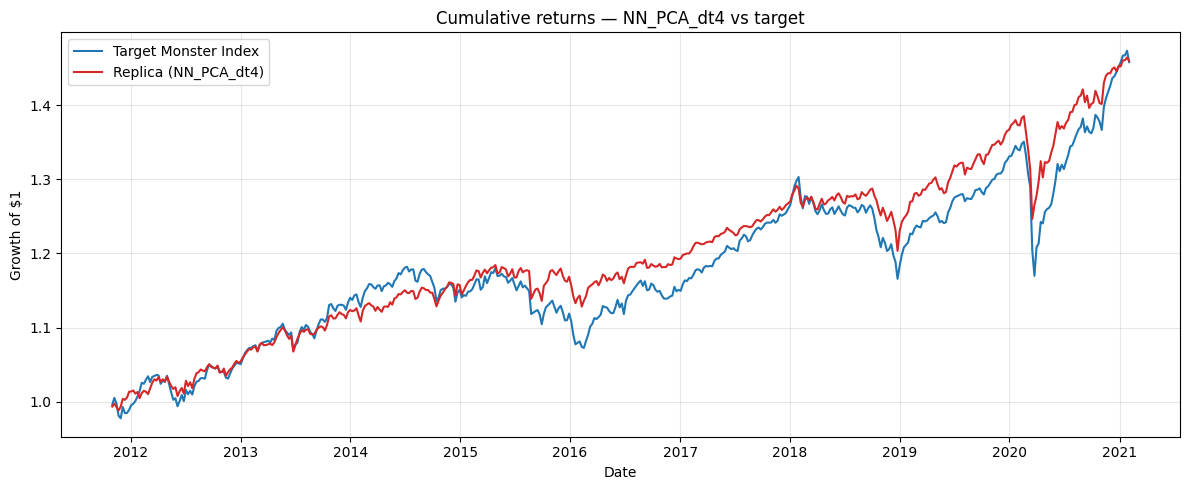

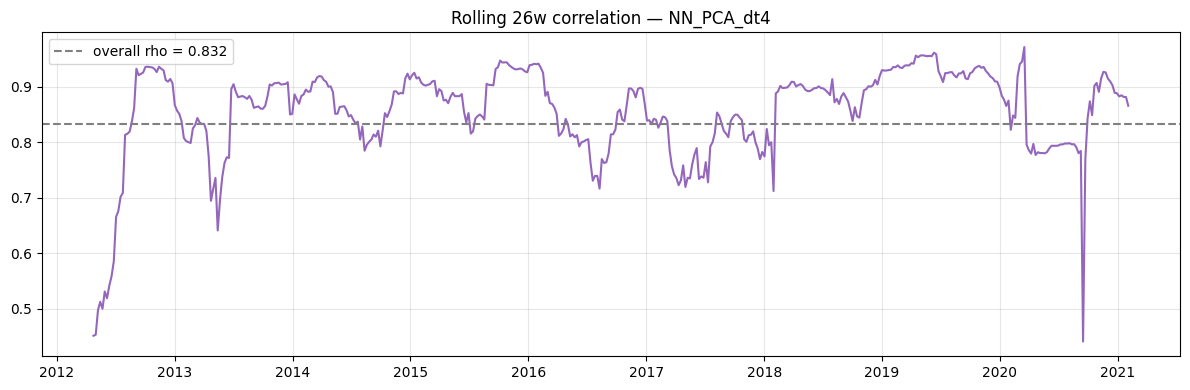

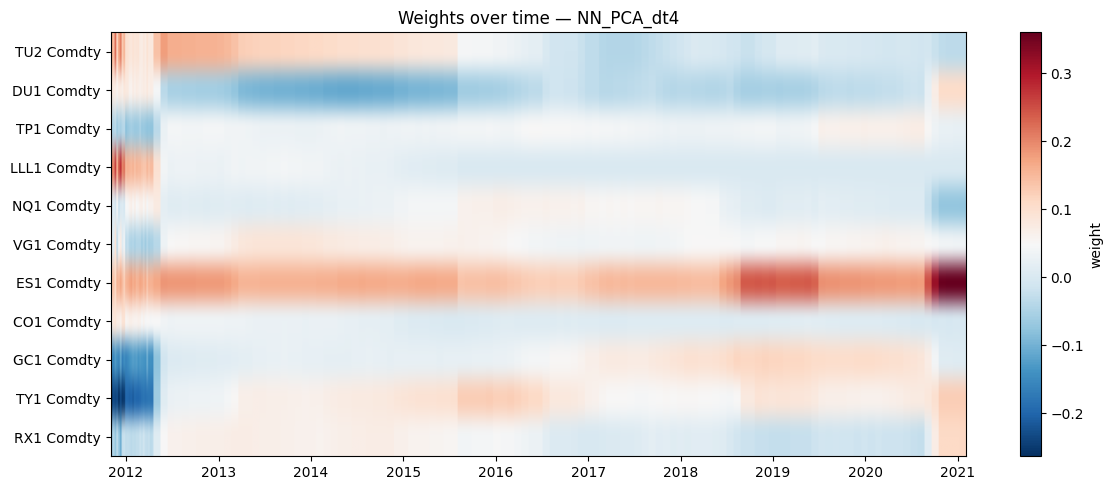

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pick the best variant by net_IR for the spotlight plots.
best_name = master_table.index[0] if not master_table.empty else next(iter(nn_results))
best = registry[best_name]

target_oos = (
    best["target_returns"]
    if "target_returns" in best
    else y.loc[best["replica_returns"].index]
)
replica_oos = best["replica_returns"]
weights_df = best["weights_history"]

cum_target = (1.0 + target_oos).cumprod()
cum_replica = (1.0 + replica_oos).cumprod()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(
    cum_target.index, cum_target.values, label="Target Monster Index", color="tab:blue"
)
ax.plot(
    cum_replica.index,
    cum_replica.values,
    label=f"Replica ({best_name})",
    color="tab:red",
)
ax.set_title(f"Cumulative returns — {best_name} vs target")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
roll_corr = replica_oos.rolling(26).corr(target_oos)
ax.plot(roll_corr.index, roll_corr.values, color="tab:purple")
ax.axhline(
    best["metrics"]["rho"],
    color="grey",
    linestyle="--",
    label=f"overall rho = {best['metrics']['rho']:.3f}",
)
ax.set_title(f"Rolling 26w correlation — {best_name}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
heat = weights_df.T.values
extent = [
    mdates.date2num(weights_df.index[0]),
    mdates.date2num(weights_df.index[-1]),
    -0.5,
    weights_df.shape[1] - 0.5,
]
im = ax.imshow(heat, aspect="auto", extent=extent, cmap="RdBu_r", origin="lower")
ax.set_yticks(range(weights_df.shape[1]))
ax.set_yticklabels(weights_df.columns)
ax.xaxis_date()
ax.set_title(f"Weights over time — {best_name}")
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()
